# Master PCA Runner
Loads processed bundle data and runs all PCA plot families from `pca_plotting.py`.


## Imports
Loads prep/plot modules plus basic libraries used for config and quick checks.


In [31]:
from pathlib import Path
import importlib
import numpy as np
import pandas as pd

import pca_data_prep as prep
import pca_plotting as plots

# Always reload local modules so notebook uses latest patched code.
prep = importlib.reload(prep)
plots = importlib.reload(plots)

print('pca_data_prep path:', Path(prep.__file__).resolve())
if not hasattr(prep, 'extract_probe_letters'):
    raise AttributeError(
        'Loaded pca_data_prep does not expose extract_probe_letters. '
        'Restart kernel and re-run this cell, then confirm it points to master/pca_data_prep.py.'
    )


pca_data_prep path: C:\Users\user\Documents\github\PCA_on_neural_data\master\pca_data_prep.py


## Load or Auto-Build Processed Bundle
Loads `merged_dic`, `stim_df`, and `pca_event_meta` from `processed_data/bundle_latest`.
If the bundle is missing, this cell can auto-build it from an NWB file for the current recording.


In [32]:
NWB_PATH = Path(r"G:\Grant\neuropixels\nwb\Reach15")
BOMBCELL_ROOT_FOR_AUTO_BUILD = Path(r"H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618")


print('Note: bombcell root folder structure must match this')
print(f'{BOMBCELL_ROOT_FOR_AUTO_BUILD}\kilosort4_A/bombcell/...')


Note: bombcell root folder structure must match this
H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_A/bombcell/...


In [33]:
baseline_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_baseline_trial_numbers_tone2_aligned.npy"
washout_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_washout_trial_numbers_tone2_aligned.npy"
optoicalStim_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_stim_allowed_trial_numbers_tone2_aligned.npy"

#load .npy files
baseline_trials_idx = np.load(baseline_trials_index_path, allow_pickle=True)
washout_trials_idx = np.load(washout_trials_index_path, allow_pickle=True)
optoicalStim_trials_idx = np.load(optoicalStim_trials_index_path, allow_pickle=True)

print('Total Baseline Trials: ', len(baseline_trials_idx))
print('Total Washout epochs: ', len(washout_trials_idx))
print('Total Optical Stim epochs: ', len(optoicalStim_trials_idx))
print('')
print('baseline_trials_idx',baseline_trials_idx)
print('optoicalStim_trials_idx',optoicalStim_trials_idx)
print('washout_trials_idx',washout_trials_idx)


Total Baseline Trials:  20
Total Washout epochs:  5
Total Optical Stim epochs:  5

baseline_trials_idx [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
optoicalStim_trials_idx [list([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
 list([61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])
 list([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120])
 list([141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160])
 list([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270])]
washout_trials_idx [list([41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])
 list([81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92

In [34]:
PROCESSED_BUNDLE_DIR = Path("processed_data") / "bundle_latest"

# If bundle is missing, optionally auto-build from NWB
AUTO_BUILD_BUNDLE_IF_MISSING = True
AUTO_REBUILD_IF_BOMBCELL_MISSING = True
NWB_PATH_FOR_AUTO_BUILD = NWB_PATH  # set to .nwb file or folder containing one .nwb

# Optional: Bombcell root (the folder that contains kilosort4_A, kilosort4_B, ...)
# Example: H:\Grant\Neuropixels\Kilosort_Recordings\...\bombcell\bombcell_batch_YYYYMMDD_HHMM
BOMBCELL_ROOT_FOR_AUTO_BUILD = BOMBCELL_ROOT_FOR_AUTO_BUILD
USE_BOMBCELL_IF_AVAILABLE = True
if USE_BOMBCELL_IF_AVAILABLE and str(BOMBCELL_ROOT_FOR_AUTO_BUILD).strip() == "":
    print("Bombcell root not set. Set BOMBCELL_ROOT_FOR_AUTO_BUILD to merge in_brainRegion/brain_region/bc_label.")

required_files = [
    PROCESSED_BUNDLE_DIR / "merged_dic.pkl",
    PROCESSED_BUNDLE_DIR / "stim_df.pkl",
    PROCESSED_BUNDLE_DIR / "pca_event_meta.pkl",
]

bundle_exists = all(f.exists() for f in required_files)
rebuild_required = (not bundle_exists)

# If bundle exists but lacks Bombcell columns, optionally rebuild
if bundle_exists and AUTO_REBUILD_IF_BOMBCELL_MISSING:
    try:
        _bundle_tmp = prep.load_processed_bundle(PROCESSED_BUNDLE_DIR)
        _md = _bundle_tmp["merged_dic"]
        _probe0 = sorted(list(_md.keys()))[0]
        _cols0 = set(_md[_probe0].columns)
        _has_bombcell_cols = ("in_brainRegion" in _cols0) and ("brain_region" in _cols0)
        if (not _has_bombcell_cols) and USE_BOMBCELL_IF_AVAILABLE and str(BOMBCELL_ROOT_FOR_AUTO_BUILD).strip() != "":
            print("Existing bundle missing Bombcell columns. Rebuild requested.")
            rebuild_required = True
    except Exception as _e:
        print("Could not inspect existing bundle; rebuild requested:", _e)
        rebuild_required = True

if rebuild_required and AUTO_BUILD_BUNDLE_IF_MISSING:
    if str(NWB_PATH_FOR_AUTO_BUILD).strip() == "":
        raise ValueError(
            "Processed bundle is missing/rebuild requested and NWB_PATH_FOR_AUTO_BUILD is empty. "
            "Set NWB_PATH_FOR_AUTO_BUILD to your recording .nwb path (or parent folder) and re-run."
        )

    print("Building processed bundle from NWB:", NWB_PATH_FOR_AUTO_BUILD)
    tables = prep.load_nwb_tables(NWB_PATH_FOR_AUTO_BUILD)

    df_units = tables["df_units"]
    df_trials = tables["df_trials"]
    if df_units.empty:
        raise ValueError("NWB units table is empty; cannot build processed bundle.")
    if df_trials.empty:
        raise ValueError("NWB trials table is empty; cannot build processed bundle.")

    qm_dic = None
    cluster_dic = None
    bombcell_report = None

    if USE_BOMBCELL_IF_AVAILABLE and str(BOMBCELL_ROOT_FOR_AUTO_BUILD).strip() != "":
        _probe_col = prep.find_probe_col(df_units)
        if _probe_col is None:
            print("Bombcell merge skipped: no probe column found in df_units.")
        else:
            if hasattr(prep, "extract_probe_letters"):
                _probes = prep.extract_probe_letters(df_units, probe_col=_probe_col)
            else:
                # Backward-compatible fallback for stale/older module objects.
                _probes = sorted(df_units[_probe_col].dropna().astype(str).str.upper().str.extract(r"([A-F])", expand=False).dropna().unique().tolist())

            if len(_probes) == 0:
                print("Bombcell merge skipped: could not infer probe labels from df_units probe column.")
            else:
                try:
                    qm_dic, cluster_dic, bombcell_report = prep.load_bombcell_metrics(
                        bombcell_root=BOMBCELL_ROOT_FOR_AUTO_BUILD,
                        probes=_probes,
                    )
                    print("Bombcell loaded qmetrics probes:", sorted(list(qm_dic.keys())) if qm_dic else [])
                    print("Bombcell loaded cluster probes:", sorted(list(cluster_dic.keys())) if cluster_dic else [])
                    if bombcell_report is not None and len(bombcell_report.get("missing", [])) > 0:
                        print("Bombcell missing entries:", bombcell_report["missing"][:10])
                except Exception as e:
                    print("Bombcell load failed; continuing without Bombcell merge:", e)
                    qm_dic = None
                    cluster_dic = None
                    bombcell_report = {"error": str(e)}

    prep.build_and_save_processed_bundle(
        out_dir=PROCESSED_BUNDLE_DIR,
        df_units=df_units,
        df_trials=df_trials,
        qm_dic=qm_dic,
        cluster_dic=cluster_dic,
        all_trial_start_times=None,
        baseline_trials_idx=None,
        optoicalStim_trials_idx=None,
        washout_trials_idx=None,
        extras={
            "auto_built_from_nwb": str(NWB_PATH_FOR_AUTO_BUILD),
            "bombcell_root": str(BOMBCELL_ROOT_FOR_AUTO_BUILD) if str(BOMBCELL_ROOT_FOR_AUTO_BUILD).strip() != "" else None,
            "bombcell_report": bombcell_report,
        },
    )
    print("Built processed bundle:", PROCESSED_BUNDLE_DIR)

bundle = prep.load_processed_bundle(PROCESSED_BUNDLE_DIR)
merged_dic = bundle["merged_dic"]
stim_df = bundle["stim_df"]
df_stim = stim_df  # alias for legacy code compatibility
pca_event_meta = bundle["pca_event_meta"]
extras = bundle.get("extras", {})
meta = bundle.get("meta", {})

print("Loaded bundle:", PROCESSED_BUNDLE_DIR)
print("Meta:", meta)
print("pca_event_meta rows:", len(pca_event_meta))


Loaded bundle: processed_data\bundle_latest
Meta: {'created_at': '2026-02-27T17:36:14.067584', 'files': ['merged_dic.pkl', 'stim_df.pkl', 'pca_event_meta.pkl', 'extras.pkl'], 'n_probes': 6, 'n_events_stim_df': 1352824, 'n_events_pca_meta': 1352824}
pca_event_meta rows: 1352824


## Verify Loaded Data
Checks probe keys, table shapes, and key columns before running PCA plots.


In [35]:
all_stimROI_triggers = df_stim[df_stim['stimulus']=='reachInit_stimROI_timestamps']
stim_ROI_df = df_stim[df_stim['stimulus']=='stimROI_timestamps']
optical_df = df_stim[df_stim['stimulus']=='optical_timestamps'] 
tone2_df= df_stim[df_stim['stimulus']=='tone2_timestamps']
tone1_df = df_stim[df_stim['stimulus']=='tone1_timestamps']
# frame_events_df = df_stim_unModifed[df_stim_unModifed['stimulus']=='frame_events_timestamp']

tone1_start_times = tone1_df['start_time'].values
tone2_start_times = tone2_df['start_time'].values
stimROI_start_times = stim_ROI_df['start_time'].values
optical_start_times = optical_df['start_time'].values
all_stimROI_triggers_start_times = all_stimROI_triggers['start_time'].values
# frame_events_start_times = frame_events_df['start_time'].values

# Step 2: Create a new DataFrame with the start times of the frame events and the closest tone1 and tone2 start times
tone1_start_times[0],tone2_start_times[0],all_stimROI_triggers_start_times[0], stimROI_start_times[0], optical_start_times[0]

(np.float64(10239.4228),
 np.float64(10239.9446),
 np.float64(10239.8933),
 np.float64(10919.650066666667),
 np.float64(10919.650066666667))

In [36]:
# Drop frame-events rows permanently from stim_df
if "stimulus" not in stim_df.columns:
    raise ValueError("stim_df has no 'stimulus' column")

stim_before = len(stim_df)
stim_df = stim_df[
    ~stim_df["stimulus"].astype(str).str.strip().str.lower().isin(
        ["frame_events_timestamps", "frame_events_timestamp"]
    )
].reset_index(drop=True)
df_stim =stim_df.copy()
print(f"stim_df rows: {stim_before} -> {len(stim_df)}")
print("Remaining stimulus values:")
print(stim_df["stimulus"].astype(str).value_counts().head(20))

def _flatten_idx(x):
    if isinstance(x, np.ndarray):
        x = x.tolist()
    if not isinstance(x, (list, tuple)):
        return [int(x)]
    out = []
    for item in x:
        if isinstance(item, (list, tuple, np.ndarray)):
            out.extend(_flatten_idx(item))
        else:
            out.append(int(item))
    return out


def _normalize_trial_indices(idx_nested, n_trials):
    """
    Accept nested trial index/number groups and normalize to 0-based integer indices.
    Handles 1-based trial numbers automatically.
    Returns list[list[int]] preserving epoch nesting.
    """
    if isinstance(idx_nested, np.ndarray):
        idx_nested = idx_nested.tolist()
    if not isinstance(idx_nested, (list, tuple)):
        idx_nested = [idx_nested]

    # force epoch nesting
    epochs = []
    for ep in idx_nested:
        if isinstance(ep, (list, tuple, np.ndarray)):
            epochs.append([int(v) for v in _flatten_idx(ep)])
        else:
            epochs.append([int(ep)])

    # detect indexing convention from global max
    all_vals = [v for ep in epochs for v in ep]
    if len(all_vals) == 0:
        return [[] for _ in epochs]

    max_v = max(all_vals)
    min_v = min(all_vals)

    # 1-based if max equals n_trials and min >= 1
    one_based = (max_v <= n_trials) and (min_v >= 1)

    norm = []
    for ep in epochs:
        if one_based:
            ep0 = [v - 1 for v in ep]
        else:
            ep0 = [v for v in ep]
        ep0 = [v for v in ep0 if 0 <= v < n_trials]
        norm.append(sorted(list(set(ep0))))
    return norm


if 'all_stimROI_triggers_start_times' not in globals():
    raise ValueError("all_stimROI_triggers_start_times not found. Run the stim extraction cells first.")
if 'baseline_trials_idx' not in globals() or 'optoicalStim_trials_idx' not in globals() or 'washout_trials_idx' not in globals():
    raise ValueError("Need baseline_trials_idx, optoicalStim_trials_idx, washout_trials_idx loaded first.")

all_stimROI_triggers_start_times = np.asarray(all_stimROI_triggers_start_times, dtype=float)
n_trials_total = len(all_stimROI_triggers_start_times)

baseline_idx_epochs = _normalize_trial_indices(baseline_trials_idx, n_trials_total)
stim_idx_epochs = _normalize_trial_indices(optoicalStim_trials_idx, n_trials_total)
wash_idx_epochs = _normalize_trial_indices(washout_trials_idx, n_trials_total)

# Build metadata rows
rows = []

# baseline is epoch 0 (or baseline_1 for plotting readability)
for ep_i, ep_idx in enumerate(baseline_idx_epochs, start=1):
    for tidx in ep_idx:
        rows.append({
            "trial_index0": int(tidx),
            "trial_number": int(tidx + 1),
            "start_time": float(all_stimROI_triggers_start_times[tidx]),
            "condition": "baseline",
            "epoch_id": int(0),
            "condition_epoch": f"baseline_epoch",
        })

for ep_i, ep_idx in enumerate(stim_idx_epochs, start=1):
    for tidx in ep_idx:
        rows.append({
            "trial_index0": int(tidx),
            "trial_number": int(tidx + 1),
            "start_time": float(all_stimROI_triggers_start_times[tidx]),
            "condition": "stimulation",
            "epoch_id": int(ep_i),
            "condition_epoch": f"stimulation_epoch_{ep_i}",
        })

for ep_i, ep_idx in enumerate(wash_idx_epochs, start=1):
    for tidx in ep_idx:
        rows.append({
            "trial_index0": int(tidx),
            "trial_number": int(tidx + 1),
            "start_time": float(all_stimROI_triggers_start_times[tidx]),
            "condition": "washout",
            "epoch_id": int(ep_i),
            "condition_epoch": f"washout_epoch_{ep_i}",
        })

pca_event_meta = pd.DataFrame(rows).drop_duplicates(subset=["trial_index0"]).sort_values("trial_index0").reset_index(drop=True)

# Requested outputs
stimulation_trials_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "stimulation", "start_time"].to_numpy(dtype=float)
washout_trials_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "washout", "start_time"].to_numpy(dtype=float)

print("Built pca_event_meta rows:", len(pca_event_meta))
print("stimulation_trials_start_times:", len(stimulation_trials_start_times))
print("washout_trials_start_times:", len(washout_trials_start_times))
# print("\nCounts by condition/epoch:")
# print(pca_event_meta.groupby(["condition", "epoch_id"]).size())
print('\n')
baseline_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "baseline", "start_time"].to_numpy(dtype=float)
stimulation_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "stimulation", "start_time"].to_numpy(dtype=float)
washout_start_times = pca_event_meta.loc[pca_event_meta["condition"] == "washout", "start_time"].to_numpy(dtype=float)
print("Baseline trials:", len(baseline_start_times), "\n     start_times range:", baseline_start_times.min(), "-", baseline_start_times.max())
print("Stimulation trials:", len(stimulation_start_times), "\n     start_times range:", stimulation_start_times.min(), "-", stimulation_start_times.max())
print("Washout trials:", len(washout_start_times), "\n     start_times range:", washout_start_times.min(), "-", washout_start_times.max())


pca_event_meta.head(3)


stim_df rows: 1352824 -> 3006
Remaining stimulus values:
stimulus
optical_timestamps              1900
tone1_timestamps                 376
reachInit_stimROI_timestamps     270
tone2_timestamps                 270
stimROI_timestamps               130
opto_tagging_timestamps           60
Name: count, dtype: int64
Built pca_event_meta rows: 270
stimulation_trials_start_times: 130
washout_trials_start_times: 120


Baseline trials: 20 
     start_times range: 10239.8933 - 10893.505433333334
Stimulation trials: 130 
     start_times range: 10919.65 - 18785.4879
Washout trials: 120 
     start_times range: 11432.124666666667 - 18502.825833333332


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
0,0,1,10239.893300,baseline,0,baseline_epoch
1,1,2,10263.343867,baseline,0,baseline_epoch
2,2,3,10285.494367,baseline,0,baseline_epoch


In [49]:
print("Probes:", sorted(list(merged_dic.keys())))
PCA_SELECTED_PROBES = sorted(list(merged_dic.keys()))
print("PCA_SELECTED_PROBES:", PCA_SELECTED_PROBES)
print("stim_df shape:", stim_df.shape)
print("pca_event_meta shape:", pca_event_meta.shape)
print("pca_event_meta columns:", list(pca_event_meta.columns))

first_probe = sorted(list(merged_dic.keys()))[0]
print("\nExample probe:", first_probe)
print("units:", len(merged_dic[first_probe]))
print("columns:", list(merged_dic[first_probe].columns))

if "brain_region" in merged_dic[first_probe].columns:
    print("brain_region unique:", pd.Series(merged_dic[first_probe]["brain_region"]).dropna().astype(str).unique()[:20])

pca_event_meta.head(3)

# quick Bombcell merge check per probe
for _p in sorted(list(merged_dic.keys())):
    _cols = set(merged_dic[_p].columns)
    print(f"Probe {_p}: in_brainRegion={'in_brainRegion' in _cols}, brain_region={'brain_region' in _cols}, bc_label={'bc_label' in _cols}")


Probes: ['A', 'B', 'C', 'D', 'E', 'F']
PCA_SELECTED_PROBES: ['A', 'B', 'C', 'D', 'E', 'F']
stim_df shape: (3006, 10)
pca_event_meta shape: (270, 6)
pca_event_meta columns: ['trial_index0', 'trial_number', 'start_time', 'condition', 'epoch_id', 'condition_epoch']

Example probe: A
units: 554
columns: ['depth', 'xpos', 'ypos', 'label', 'KSlabel', 'KSamplitude', 'KScontamination', 'probe', 'spike_times', 'cluster_id', 'nSpikes', 'maxDriftEstimate', 'maxChannels', 'bc_label', 'in_brainRegion', 'brain_region']
brain_region unique: ['SIM' 'IP']
Probe A: in_brainRegion=True, brain_region=True, bc_label=True
Probe B: in_brainRegion=True, brain_region=True, bc_label=True
Probe C: in_brainRegion=True, brain_region=True, bc_label=True
Probe D: in_brainRegion=True, brain_region=True, bc_label=True
Probe E: in_brainRegion=True, brain_region=True, bc_label=True
Probe F: in_brainRegion=True, brain_region=True, bc_label=True


In [38]:
probe = 'A'
merged_dic[probe][0:3]

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,in_brainRegion,brain_region
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,"[9938.427594575005, 9938.443329123113, 9938.44...",0,14579.0,29.717560,52,NOISE,IN_ROI,SIM
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,"[9938.363989665882, 9938.408826460065, 9938.42...",1,35469.0,93.164818,52,NOISE,IN_ROI,SIM
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,"[9938.135738714089, 9939.27045963741, 9940.801...",2,176.0,4.297394,5,NOISE,IN_ROI,SIM


In [39]:
pca_event_meta

,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
0,0,1,10239.893300,baseline,0,baseline_epoch
1,1,2,10263.343867,baseline,0,baseline_epoch
2,2,3,10285.494367,baseline,0,baseline_epoch
3,3,4,10306.931567,baseline,0,baseline_epoch
4,4,5,10383.171333,baseline,0,baseline_epoch
...,...,...,...,...,...,...
265,265,266,18693.912033,stimulation,5,stimulation_epoch_5
266,266,267,18714.177167,stimulation,5,stimulation_epoch_5
267,267,268,18743.100500,stimulation,5,stimulation_epoch_5
268,268,269,18764.043367,stimulation,5,stimulation_epoch_5


## Global Plot Config
Sets output root, PCA binning, filters, and smoothing used by all plot calls.


In [40]:
PLOTS_SAVE_ROOT = PROCESSED_BUNDLE_DIR / "plots"

WINDOW_START_S = -1.0
WINDOW_END_S = 1.0
BIN_SIZE_S = 0.025
MAX_TENSOR_GB = 8.0
N_COMPONENTS = 12
SMOOTH_SIGMA = 1.5

EPOCH_PCA_PROBE = "A"
EPOCH_PCA_BRAIN_REGION = None   # None => first available region after filtering
EPOCH_PCA_ROI_FILTER = "IN_ROI"  # None, "IN_ROI", "OUT_ROI"
EPOCH_PCA_KSLABEL_FILTER = "both"  # "both", "good", "mua"
EPOCH_PCA_INCLUDE_CONDITIONS = ["baseline", "stimulation", "washout"]

SHOW_PLOTS_SINGLE = True
SHOW_PLOTS_BATCH = False


## Build Single Probe Inputs
Filters units by probe/ROI/KS/brain_region, bins spikes around epoch events, and computes trial-level PCA.


In [42]:
_available_regions = plots._list_probe_brain_regions(
    merged_dic=merged_dic,
    probe=EPOCH_PCA_PROBE,
    roi_filter=EPOCH_PCA_ROI_FILTER,
    kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
)
if len(_available_regions) == 0:
    raise ValueError(f"No brain regions found for probe {EPOCH_PCA_PROBE} after ROI/KS filtering.")

if EPOCH_PCA_BRAIN_REGION is None:
    EPOCH_PCA_BRAIN_REGION = _available_regions[0]

if EPOCH_PCA_BRAIN_REGION not in _available_regions:
    raise ValueError(f"brain_region {EPOCH_PCA_BRAIN_REGION} not available. Available: {_available_regions}")

event_meta_probe, trials_ec, time_ec, Xp_ec, evr_ec = plots.run_epoch_condition_pca_for_probe(
    probe=EPOCH_PCA_PROBE,
    merged_dic=merged_dic,
    event_meta=pca_event_meta,
    roi_filter=EPOCH_PCA_ROI_FILTER,
    kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
    include_conditions=EPOCH_PCA_INCLUDE_CONDITIONS,
    n_components=max(3, N_COMPONENTS),
    max_tensor_gb=MAX_TENSOR_GB,
    win_start_s=WINDOW_START_S,
    win_end_s=WINDOW_END_S,
    bin_size_s=BIN_SIZE_S,
    brain_region_filter=EPOCH_PCA_BRAIN_REGION,
)

plot_title = f"Probe {EPOCH_PCA_PROBE} | ROI={EPOCH_PCA_ROI_FILTER} | KS={EPOCH_PCA_KSLABEL_FILTER} | BR={EPOCH_PCA_BRAIN_REGION}"
brain_region_subtitle = plots.probe_brain_region_label(
    merged_dic=merged_dic,
    probe=EPOCH_PCA_PROBE,
    roi_filter=EPOCH_PCA_ROI_FILTER,
    kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
)

print("Events:", len(event_meta_probe), "Units:", trials_ec.shape[1])
print("EVR first 5:", np.round(evr_ec[:5], 4))
print(brain_region_subtitle)


Requested tensor shape=(270, 72, 80) est_mem=0.01 GB
Events: 270 Units: 72
EVR first 5: [0.4233 0.1743 0.0464 0.0224 0.0203]
brain_region: IP, SIM, unknown


## Group 1: Base Trial-Level Epoch Plot Set
Creates one large figure with 3 subplots:
- 2D PC1/PC2 scatter
- 3D PC1/PC2/PC3 scatter
- 3D PC1/PC2/Time


c:\Users\user\Documents\github\PCA_on_neural_data\master\pca_plotting.py:2676: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.9])


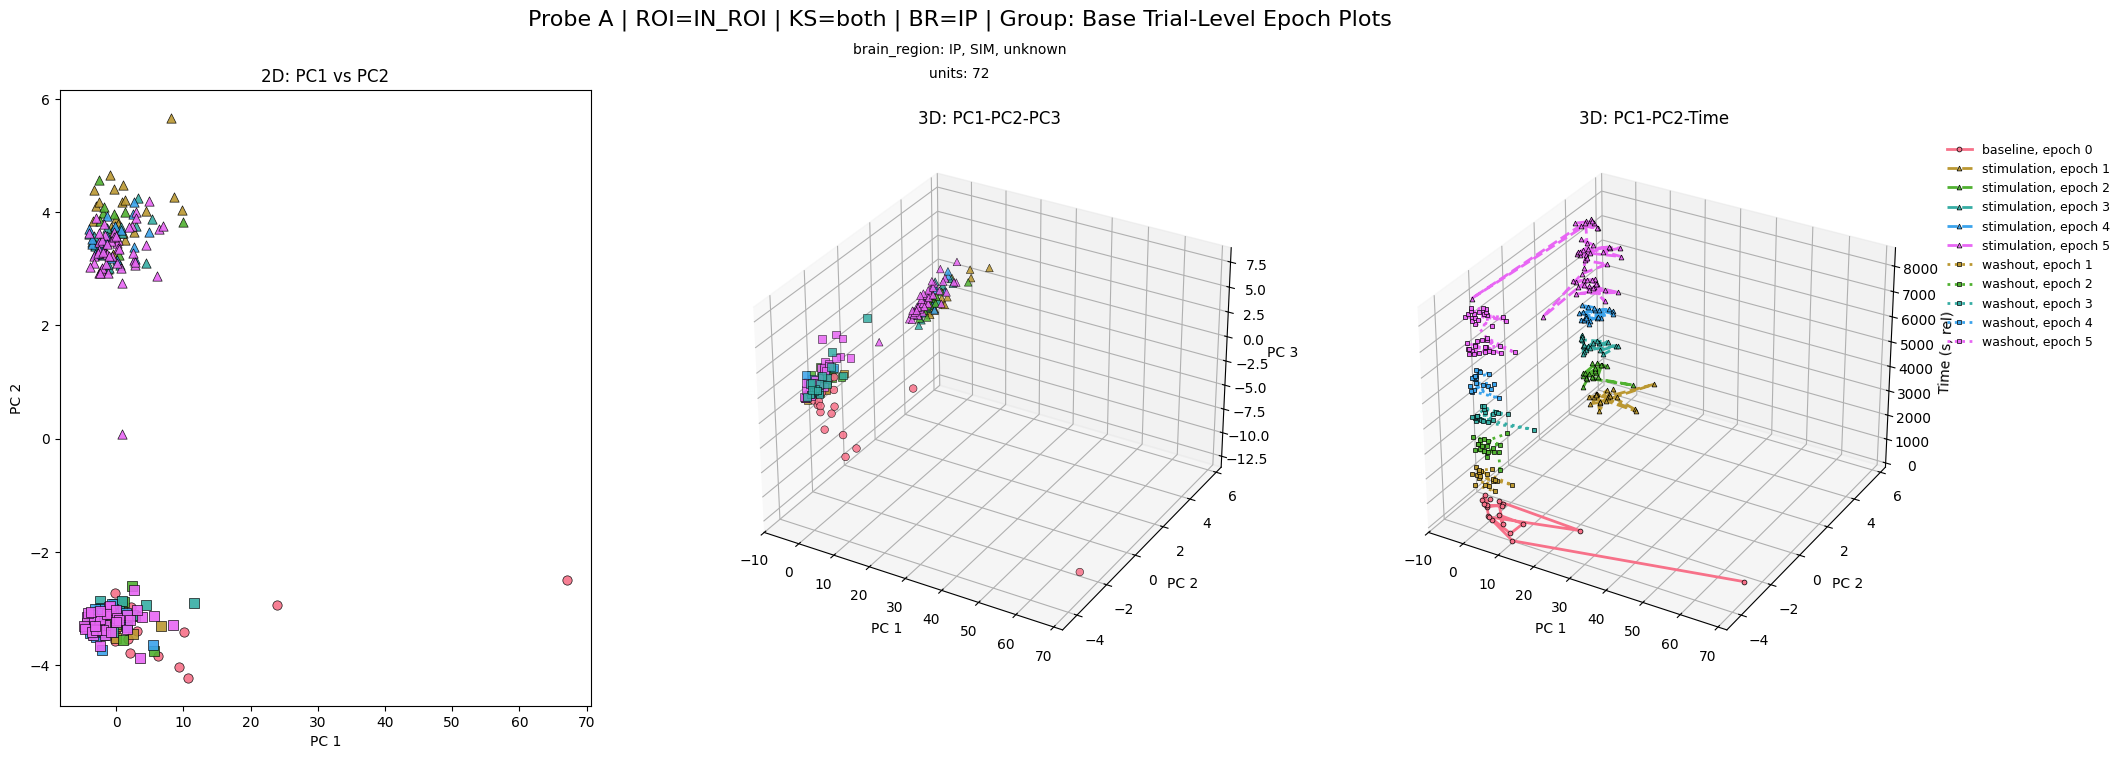

In [43]:
plots.plot_epoch_condition_group_base_trial(
    Xp=Xp_ec,
    event_meta=event_meta_probe,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    time_col="start_time",
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_ROOT,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Group 2: Epoch-Mean Plot Set
Creates one large figure with 4 subplots:
- 2D epoch-mean
- 3D epoch-mean
- 3D epoch-mean PC1/PC2/Time points
- 3D epoch-mean PC1/PC2/Time lines


c:\Users\user\Documents\github\PCA_on_neural_data\master\pca_plotting.py:2798: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.92])


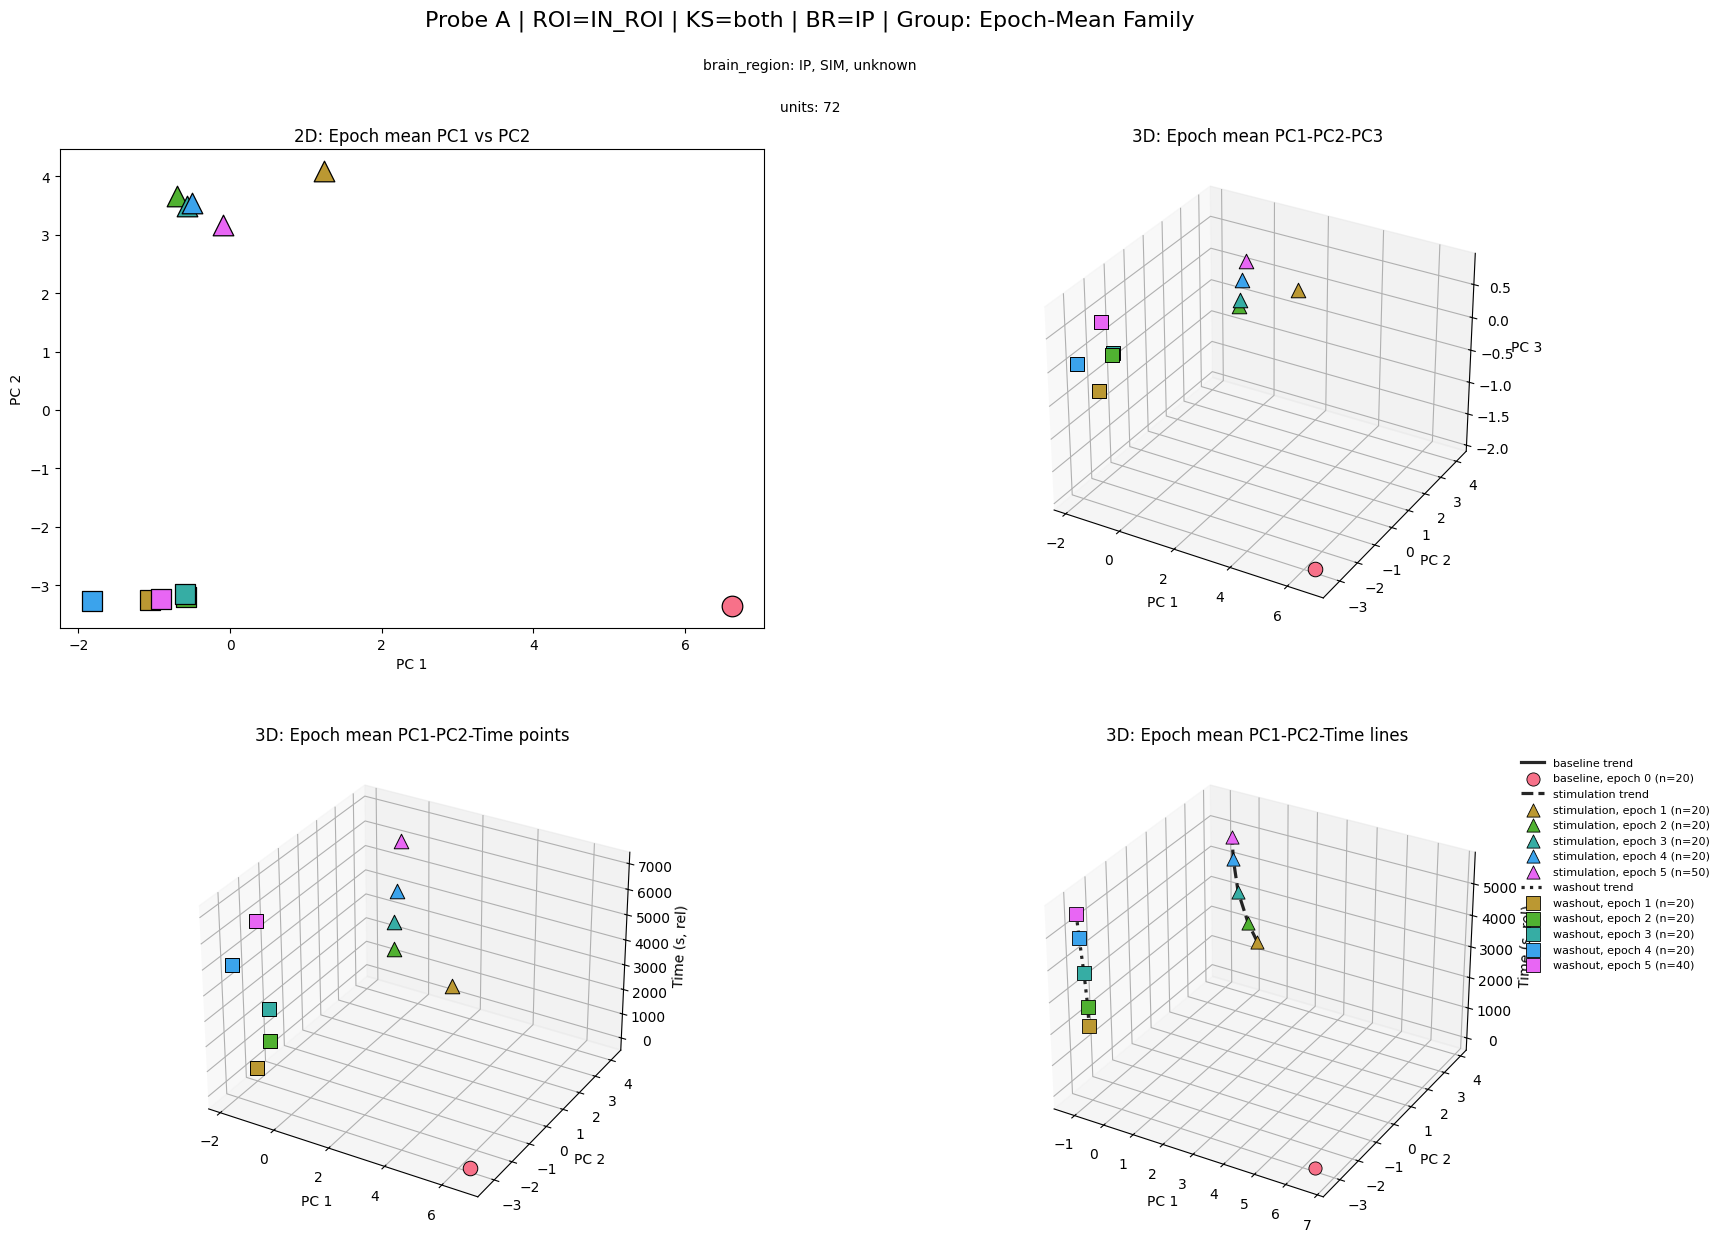

In [44]:
plots.plot_epoch_condition_group_epochmean(
    Xp=Xp_ec,
    event_meta=event_meta_probe,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    smooth_sigma=SMOOTH_SIGMA,
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_ROOT,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Group 3: Per-Trial Time-Bin Plot Set
Creates one large figure with 3 subplots from trial-level time-bin PCA trajectories:
- 2D lines
- 3D PC1/PC2/PC3 lines
- 3D PC1/PC2/Time lines


Trial-time PCA EVR first 5: [0.1834 0.1435 0.0341 0.0283 0.0266]


c:\Users\user\Documents\github\PCA_on_neural_data\master\pca_plotting.py:2892: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.9])


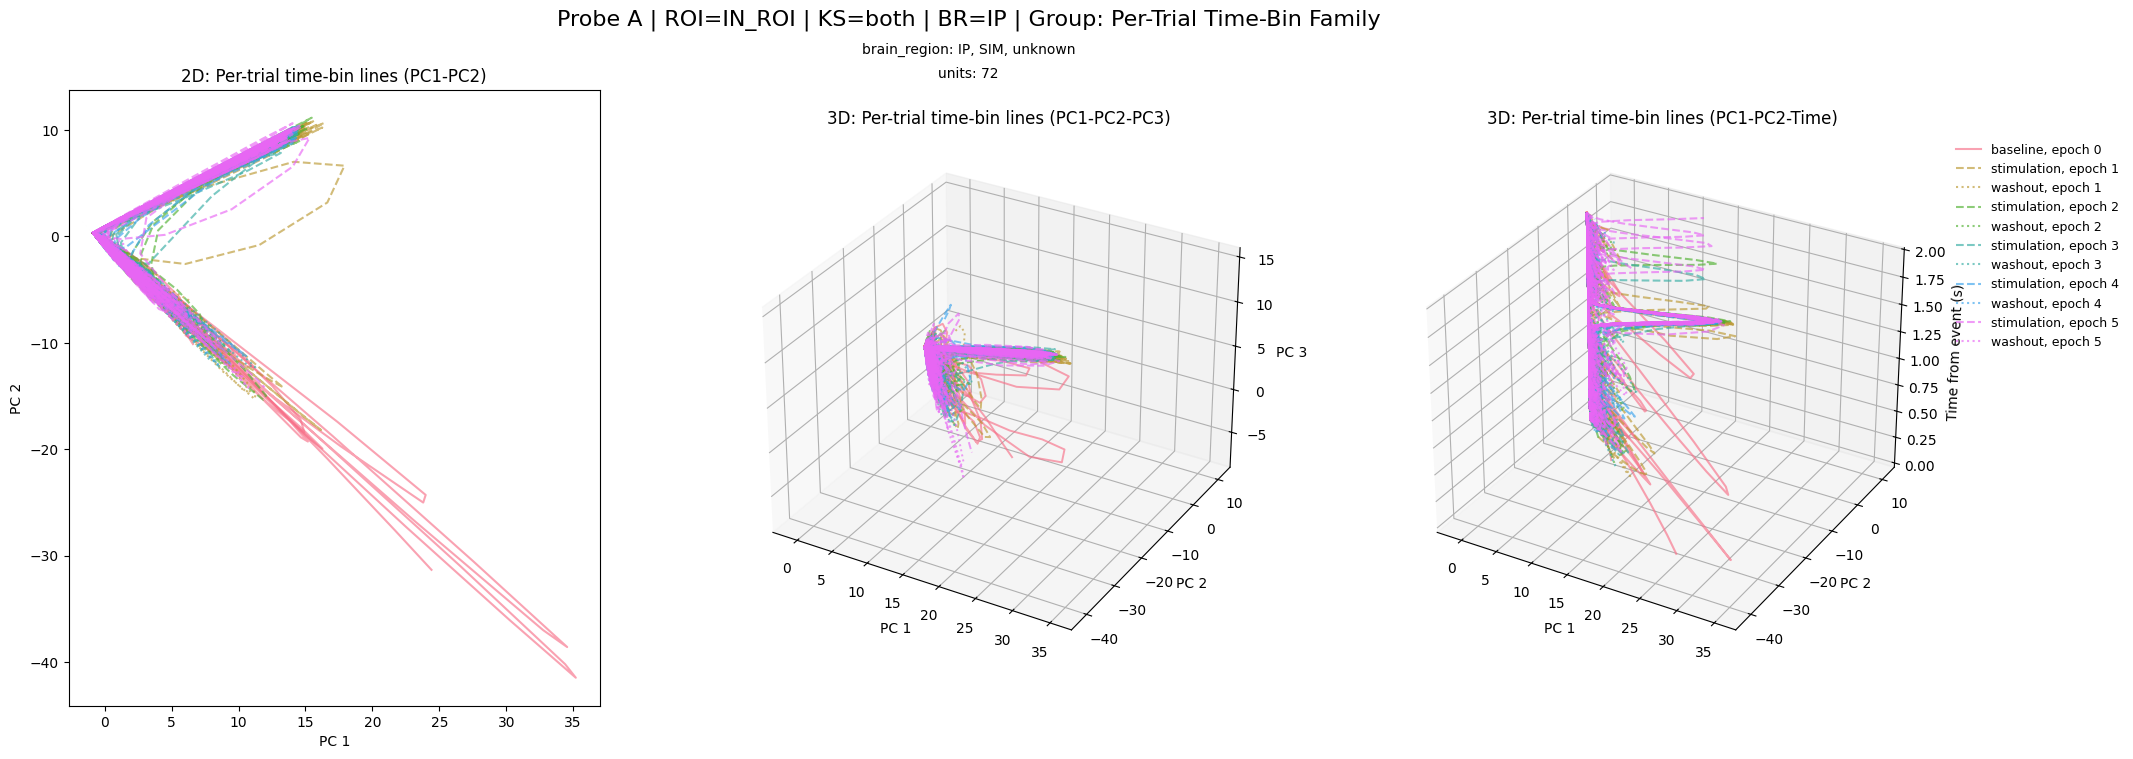

In [45]:
trial_time_scores, trial_time_evr = plots.pca_trial_timebin_scores(
    trials=trials_ec,
    n_components=max(3, N_COMPONENTS),
)
print("Trial-time PCA EVR first 5:", np.round(trial_time_evr[:5], 4))

plots.plot_epoch_condition_group_trial_time(
    trial_time_scores=trial_time_scores,
    event_meta=event_meta_probe,
    bin_time=time_ec,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    smooth_sigma=SMOOTH_SIGMA,
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_ROOT,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Group 4: One-Line-Per-Epoch Population Plot Set
Creates one large figure with 3 subplots from epoch-averaged population trajectories:
- 2D lines
- 3D PC1/PC2/PC3 lines
- 3D PC1/PC2/Time lines


Epoch-population PCA EVR first 5: [0.2251 0.1847 0.0349 0.0286 0.0274]


c:\Users\user\Documents\github\PCA_on_neural_data\master\pca_plotting.py:2984: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.9])


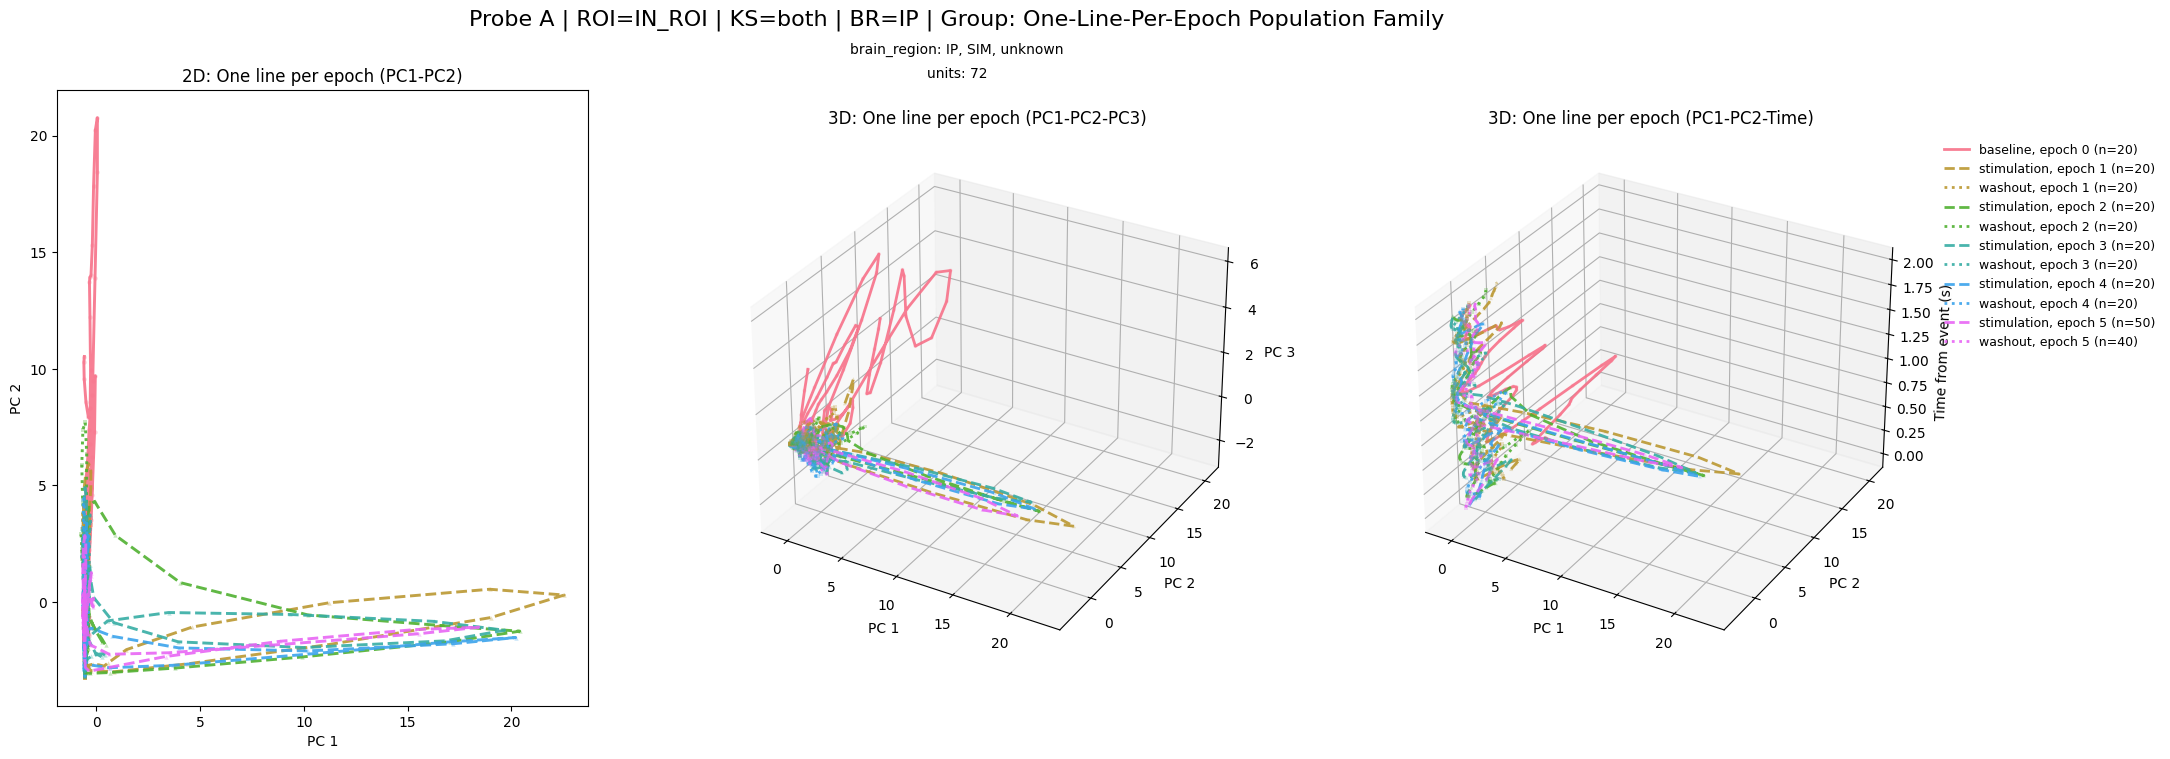

In [46]:
epoch_info_df, epoch_traj, epoch_evr = plots.pca_epoch_population_timebin_trajectories(
    trials=trials_ec,
    event_meta=event_meta_probe,
    n_components=max(3, N_COMPONENTS),
)
print("Epoch-population PCA EVR first 5:", np.round(epoch_evr[:5], 4))

plots.plot_epoch_condition_group_epoch_population(
    epoch_info_df=epoch_info_df,
    epoch_traj=epoch_traj,
    bin_time=time_ec,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    smooth_sigma=SMOOTH_SIGMA,
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_ROOT,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Optional Legacy Individual Plot Calls
These are intentionally disabled to keep grouped workflow as default.


In [47]:
print("Grouped workflow is active. Individual legacy calls are disabled in this notebook version.")


Grouped workflow is active. Individual legacy calls are disabled in this notebook version.


## Optional Legacy Individual Plot Calls (continued)


In [48]:
print("Grouped workflow is active. Individual legacy calls are disabled in this notebook version.")


Grouped workflow is active. Individual legacy calls are disabled in this notebook version.


## Batch Run Grouped Plot Sets
Runs grouped epoch-condition figure sets for each selected probe and each brain_region.


In [ ]:
BATCH_RUN_ALL = True

if BATCH_RUN_ALL:
    if "PCA_SELECTED_PROBES" in globals() and PCA_SELECTED_PROBES is not None:
        probes_to_run = [p for p in PCA_SELECTED_PROBES if p in merged_dic]
    else:
        probes_to_run = sorted(list(merged_dic.keys()))

    for probe in probes_to_run:
        regions = plots._list_probe_brain_regions(
            merged_dic=merged_dic,
            probe=probe,
            roi_filter=EPOCH_PCA_ROI_FILTER,
            kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
        )
        if len(regions) == 0:
            print(f"Probe {probe}: skipped (no brain regions)")
            continue

        for br in regions:
            try:
                em, trials, tbins, Xp, evr = plots.run_epoch_condition_pca_for_probe(
                    probe=probe,
                    merged_dic=merged_dic,
                    event_meta=pca_event_meta,
                    roi_filter=EPOCH_PCA_ROI_FILTER,
                    kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
                    include_conditions=EPOCH_PCA_INCLUDE_CONDITIONS,
                    n_components=max(3, N_COMPONENTS),
                    max_tensor_gb=MAX_TENSOR_GB,
                    win_start_s=WINDOW_START_S,
                    win_end_s=WINDOW_END_S,
                    bin_size_s=BIN_SIZE_S,
                    brain_region_filter=br,
                )
            except Exception as e:
                print(f"Probe {probe} | BR={br}: skipped due to {e}")
                continue

            subtitle = plots.probe_brain_region_label(
                merged_dic=merged_dic,
                probe=probe,
                roi_filter=EPOCH_PCA_ROI_FILTER,
                kslabel_filter=EPOCH_PCA_KSLABEL_FILTER,
                brain_region_filter=br,
            )
            title = f"Probe {probe} | ROI={EPOCH_PCA_ROI_FILTER} | KS={EPOCH_PCA_KSLABEL_FILTER} | BR={br}"
            n_units = trials.shape[1]

            print(f"Running grouped batch plots for probe={probe}, BR={br}, units={n_units}, events={len(em)}")

            # Group 1
            plots.plot_epoch_condition_group_base_trial(
                Xp=Xp,
                event_meta=em,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                time_col="start_time",
                n_units=n_units,
                save_root=PLOTS_SAVE_ROOT,
                show_plots=SHOW_PLOTS_BATCH,
            )

            # Group 2
            plots.plot_epoch_condition_group_epochmean(
                Xp=Xp,
                event_meta=em,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                smooth_sigma=SMOOTH_SIGMA,
                n_units=n_units,
                save_root=PLOTS_SAVE_ROOT,
                show_plots=SHOW_PLOTS_BATCH,
            )

            # Group 3
            scores, scores_evr = plots.pca_trial_timebin_scores(trials, n_components=max(3, N_COMPONENTS))
            print("  trial-time EVR first 3:", np.round(scores_evr[:3], 4))
            plots.plot_epoch_condition_group_trial_time(
                trial_time_scores=scores,
                event_meta=em,
                bin_time=tbins,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                smooth_sigma=SMOOTH_SIGMA,
                n_units=n_units,
                save_root=PLOTS_SAVE_ROOT,
                show_plots=SHOW_PLOTS_BATCH,
            )

            # Group 4
            epoch_info, epoch_traj, epoch_evr = plots.pca_epoch_population_timebin_trajectories(
                trials,
                em,
                n_components=max(3, N_COMPONENTS),
            )
            print("  epoch-population EVR first 3:", np.round(epoch_evr[:3], 4))
            plots.plot_epoch_condition_group_epoch_population(
                epoch_info_df=epoch_info,
                epoch_traj=epoch_traj,
                bin_time=tbins,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                smooth_sigma=SMOOTH_SIGMA,
                n_units=n_units,
                save_root=PLOTS_SAVE_ROOT,
                show_plots=SHOW_PLOTS_BATCH,
            )
else:
    print("Set BATCH_RUN_ALL=True to run grouped batch plotting")
